In [1]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))
print("Setup OK ✓")

TensorFlow version: 2.21.0
GPU available: []
Setup OK ✓


In [3]:
# ---- EDIT THESE PATHS TO MATCH YOUR MACHINE ----
ORIGINAL_DATASET_DIR = r"kaggle_dataset_2018"
EXTRA_TEST_DIR       = r"kaggle_dataset2_2020\MedicalExpert-I"

# Where we'll create the new ternary-class folders
TERNARY_DIR = r"\ternary_dataset"
# -------------------------------------------------

# Verify paths exist
for split in ['train', 'val', 'test']:
    p = os.path.join(ORIGINAL_DATASET_DIR, split)
    assert os.path.isdir(p), f"Folder NOT found: {p}"
    print(f"✓ Found: {p}")
print(f"✓ Extra test set: {EXTRA_TEST_DIR}")


✓ Found: kaggle_dataset_2018\train
✓ Found: kaggle_dataset_2018\val
✓ Found: kaggle_dataset_2018\test
✓ Extra test set: kaggle_dataset2_2020\MedicalExpert-I


## Conversion of 5-class to 3-class ( HEALTHY , MODERATE , SEVERE)

In [23]:
# Delete old ternary folder first
import shutil, os
if os.path.exists(TERNARY_DIR):
    shutil.rmtree(TERNARY_DIR)
if os.path.exists(EXTRA_TERNARY_DIR):
    shutil.rmtree(EXTRA_TERNARY_DIR)

# NEW improved mapping
GRADE_MAP = {
    '0': 'Healthy',
    '1': 'Healthy',     # changed
    '2': 'Moderate',    # changed  
    '3': 'Severe',
    '4': 'Severe',
}

GRADE_MAP_2020 = {
    '0Normal':   'Healthy',
    '1Doubtful': 'Healthy',     # changed
    '2Mild':     'Moderate',    # changed
    '3Moderate': 'Severe',
    '4Severe':   'Severe',
}

def build_ternary_dataset(src_root, dst_root):
    if os.path.exists(dst_root):
        print(f"Ternary dataset already exists at {dst_root}. Skipping.")
        return
    for split in ['train', 'val', 'test']:
        src_split = os.path.join(src_root, split)
        for grade_folder in os.listdir(src_split):
            new_class = GRADE_MAP.get(grade_folder)
            if new_class is None:
                continue
            src_dir = os.path.join(src_split, grade_folder)
            dst_dir = os.path.join(dst_root, split, new_class)
            os.makedirs(dst_dir, exist_ok=True)
            for fname in os.listdir(src_dir):
                shutil.copy2(os.path.join(src_dir, fname),
                             os.path.join(dst_dir, fname))
        print(f"✓ Built {split}")

build_ternary_dataset(ORIGINAL_DATASET_DIR, TERNARY_DIR)

# Show counts
print("Final class counts:")
for split in ['train', 'val', 'test']:
    print(f"{split}:")
    for cls in sorted(os.listdir(os.path.join(TERNARY_DIR, split))):
        n = len(os.listdir(os.path.join(TERNARY_DIR, split, cls)))
        print(f"  {cls:10s}: {n} images")

✓ Built train
✓ Built val
✓ Built test
Final class counts:
train:
  Healthy   : 3332 images
  Moderate  : 1516 images
  Severe    : 930 images
val:
  Healthy   : 481 images
  Moderate  : 212 images
  Severe    : 133 images
test:
  Healthy   : 935 images
  Moderate  : 447 images
  Severe    : 274 images


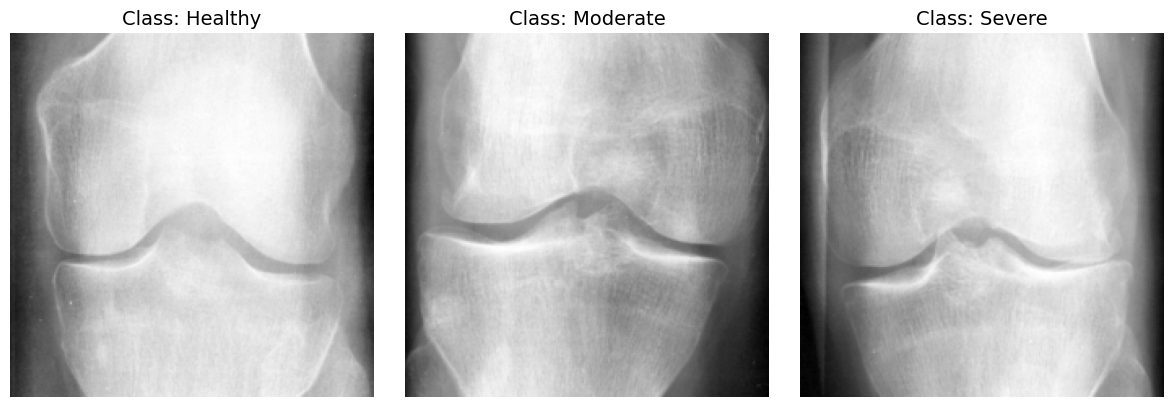

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, cls in enumerate(['Healthy', 'Moderate', 'Severe']):
    folder = os.path.join(TERNARY_DIR, 'train', cls)
    img_name = os.listdir(folder)[0]
    img = Image.open(os.path.join(folder, img_name))
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'Class: {cls}', fontsize=14)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

## Data Generators ( Augmentation)

In [25]:
IMG_SIZE = 320
BATCH_SIZE = 32

import cv2

def clahe_preprocess(img):
    """Apply CLAHE then EfficientNet preprocessing."""
    img = img.astype(np.uint8)
    # Convert to grayscale, apply CLAHE, convert back to 3 channels
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    img_3ch = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB).astype('float32')
    return preprocess_input(img_3ch)

train_datagen = ImageDataGenerator(
    preprocessing_function=clahe_preprocess,
    rotation_range=20,                  # increased
    width_shift_range=0.15,             # increased
    height_shift_range=0.15,            # increased
    horizontal_flip=True,
    zoom_range=0.15,                    # increased
    brightness_range=[0.8, 1.2],
    shear_range=10,                     # NEW
    fill_mode='reflect',
)

eval_datagen = ImageDataGenerator(preprocessing_function=clahe_preprocess)


train_gen = train_datagen.flow_from_directory(
    os.path.join(TERNARY_DIR, 'train'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
)
val_gen = eval_datagen.flow_from_directory(
    os.path.join(TERNARY_DIR, 'val'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
)
test_gen = eval_datagen.flow_from_directory(
    os.path.join(TERNARY_DIR, 'test'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
)

CLASS_NAMES = list(train_gen.class_indices.keys())
print("Classes:", CLASS_NAMES)


Found 5778 images belonging to 3 classes.
Found 826 images belonging to 3 classes.
Found 1656 images belonging to 3 classes.
Classes: ['Healthy', 'Moderate', 'Severe']


In [35]:
## Mixup Augmentation (Strong Regularizers)
class MixupGenerator(tf.keras.utils.Sequence):
    def __init__(self, base_gen, alpha=0.2):
        self.base_gen = base_gen
        self.alpha = alpha
    def __len__(self): return len(self.base_gen)
    def __getitem__(self, idx):
        X1, y1 = self.base_gen[idx]
        idx2 = (idx + 1) % len(self.base_gen)
        X2, y2 = self.base_gen[idx2]
        n = min(len(X1), len(X2))
        X1, y1, X2, y2 = X1[:n], y1[:n], X2[:n], y2[:n]
        lam = np.random.beta(self.alpha, self.alpha)
        X = lam * X1 + (1 - lam) * X2
        y = lam * y1 + (1 - lam) * y2
        return X, y
    def on_epoch_end(self):
        self.base_gen.on_epoch_end()

train_gen_mixup = MixupGenerator(train_gen, alpha=0.2)

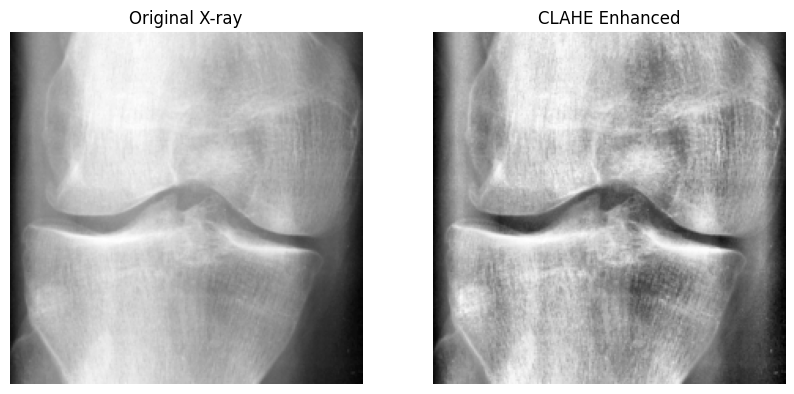

In [26]:
## Visualize the effect (good for your project report!):

sample_path = os.path.join(TERNARY_DIR, 'train', 'Moderate',os.listdir(os.path.join(TERNARY_DIR, 'train', 'Moderate'))[0])
orig = cv2.imread(sample_path)
orig_rgb = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(orig_rgb, cv2.COLOR_RGB2GRAY)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
enhanced = clahe.apply(gray)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(gray, cmap='gray'); ax[0].set_title('Original X-ray'); ax[0].axis('off')
ax[1].imshow(enhanced, cmap='gray'); ax[1].set_title('CLAHE Enhanced'); ax[1].axis('off')
plt.show()

## Compute Class Weights

In [27]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes,
)
class_weights_dict = dict(enumerate(class_weights))
print("Class weights:", class_weights_dict)

Class weights: {0: np.float64(0.578031212484994), 1: np.float64(1.270448548812665), 2: np.float64(2.0709677419354837)}


## Build the Model

In [28]:
NUM_CLASSES = 3

import tensorflow.keras.backend as K

def focal_loss(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        y_pred = K.clip(y_pred, K.epsilon(), 1.0 - K.epsilon())
        cross_entropy = -y_true * K.log(y_pred)
        weight = alpha * K.pow(1 - y_pred, gamma)
        return K.sum(weight * cross_entropy, axis=-1)
    return loss_fn

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
)
base_model.trainable = False  # freeze base for Phase 1

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy'],
)
print("Total params:", model.count_params())


Total params: 4415910


## Phase 1 Training 

In [29]:
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_model_phase1.h5', monitor='val_accuracy', save_best_only=True, verbose=1),
]

history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=callbacks,
    class_weight=class_weights_dict,
    verbose=1,
)

Epoch 1/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4288 - loss: 0.2232
Epoch 1: val_accuracy improved from None to 0.61743, saving model to best_model_phase1.h5



Epoch 1: finished saving model to best_model_phase1.h5
181/181 ━━━━━━━━━━━━━━━━━━━━ 323s 2s/step - accuracy: 0.4519 - loss: 0.1778 - val_accuracy: 0.6174 - val_loss: 0.0983 - learning_rate: 0.0010
Epoch 2/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4815 - loss: 0.1225
Epoch 2: val_accuracy improved from 0.61743 to 0.66707, saving model to best_model_phase1.h5



Epoch 2: finished saving model to best_model_phase1.h5
181/181 ━━━━━━━━━━━━━━━━━━━━ 236s 1s/step - accuracy: 0.5029 - loss: 0.1150 - val_accuracy: 0.6671 - val_loss: 0.0898 - learning_rate: 0.0010
Epoch 3/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5379 - loss: 0.1021
Epoch 3: val_accuracy improved from 0.66707 to 0.66828, saving model to best_model_phase1.h5



Epoch 3: finished saving model to best_model_phase1.h5
181/181 ━━━━━━━━━━━━━━━━━━━━ 237s 1s/step - accuracy: 0.5348 - loss: 0.1019 - val_accuracy: 0.6683 - val_loss: 0.0790 - learning_rate: 0.0010
Epoch 4/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5634 - loss: 0.0986
Epoch 4: val_accuracy improved from 0.66828 to 0.69734, saving model to best_model_phase1.h5



Epoch 4: finished saving model to best_model_phase1.h5
181/181 ━━━━━━━━━━━━━━━━━━━━ 243s 1s/step - accuracy: 0.5609 - loss: 0.0988 - val_accuracy: 0.6973 - val_loss: 0.0760 - learning_rate: 0.0010
Epoch 5/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5812 - loss: 0.0951
Epoch 5: val_accuracy did not improve from 0.69734
181/181 ━━━━━━━━━━━━━━━━━━━━ 240s 1s/step - accuracy: 0.5793 - loss: 0.0944 - val_accuracy: 0.6949 - val_loss: 0.0724 - learning_rate: 0.0010
Epoch 6/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5693 - loss: 0.0964
Epoch 6: val_accuracy did not improve from 0.69734
181/181 ━━━━━━━━━━━━━━━━━━━━ 237s 1s/step - accuracy: 0.5843 - loss: 0.0933 - val_accuracy: 0.6840 - val_loss: 0.0699 - learning_rate: 0.0010
Epoch 7/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6045 - loss: 0.0932
Epoch 7: val_accuracy did not improve from 0.69734
181/181 ━━━━━━━━━━━━━━━━━━━━ 234s 1s/step - accuracy: 0.6038 - loss: 0.0919 - val_accuracy: 0.6937 - val_loss:


Epoch 8: finished saving model to best_model_phase1.h5
181/181 ━━━━━━━━━━━━━━━━━━━━ 236s 1s/step - accuracy: 0.6052 - loss: 0.0894 - val_accuracy: 0.7010 - val_loss: 0.0686 - learning_rate: 0.0010
Epoch 9/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5902 - loss: 0.0943
Epoch 9: val_accuracy improved from 0.70097 to 0.70218, saving model to best_model_phase1.h5



Epoch 9: finished saving model to best_model_phase1.h5
181/181 ━━━━━━━━━━━━━━━━━━━━ 238s 1s/step - accuracy: 0.6075 - loss: 0.0911 - val_accuracy: 0.7022 - val_loss: 0.0718 - learning_rate: 0.0010
Epoch 10/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6076 - loss: 0.0884
Epoch 10: val_accuracy improved from 0.70218 to 0.70702, saving model to best_model_phase1.h5



Epoch 10: finished saving model to best_model_phase1.h5
181/181 ━━━━━━━━━━━━━━━━━━━━ 238s 1s/step - accuracy: 0.6097 - loss: 0.0877 - val_accuracy: 0.7070 - val_loss: 0.0700 - learning_rate: 0.0010
Epoch 11/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6177 - loss: 0.0861
Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.

Epoch 11: val_accuracy did not improve from 0.70702
181/181 ━━━━━━━━━━━━━━━━━━━━ 231s 1s/step - accuracy: 0.6163 - loss: 0.0866 - val_accuracy: 0.6622 - val_loss: 0.0699 - learning_rate: 0.0010
Epoch 12/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6204 - loss: 0.0880
Epoch 12: val_accuracy did not improve from 0.70702
181/181 ━━━━━━━━━━━━━━━━━━━━ 233s 1s/step - accuracy: 0.6234 - loss: 0.0850 - val_accuracy: 0.6949 - val_loss: 0.0663 - learning_rate: 3.0000e-04
Epoch 13/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6409 - loss: 0.0865
Epoch 13: val_accuracy did not improve from 0.70702
181/181 ━━━━━━━━━━━━━


Epoch 14: finished saving model to best_model_phase1.h5
181/181 ━━━━━━━━━━━━━━━━━━━━ 242s 1s/step - accuracy: 0.6376 - loss: 0.0835 - val_accuracy: 0.7203 - val_loss: 0.0656 - learning_rate: 3.0000e-04
Epoch 15/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6511 - loss: 0.0818
Epoch 15: val_accuracy did not improve from 0.72034
181/181 ━━━━━━━━━━━━━━━━━━━━ 233s 1s/step - accuracy: 0.6483 - loss: 0.0826 - val_accuracy: 0.7082 - val_loss: 0.0658 - learning_rate: 3.0000e-04


## Phase 2 Training ( Unfreeze top layers )

In [30]:
# Unfreeze top 30 layers
base_model.trainable = True
for layer in base_model.layers[:-60]:
    layer.trainable = False

# Recompile with lower learning rate (CRITICAL)
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy'],
)

callbacks_ft = [
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-8, verbose=1),
    ModelCheckpoint('best_model_final.h5', monitor='val_accuracy', save_best_only=True, verbose=1),
]

history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=callbacks_ft,
    class_weight=class_weights_dict,
    verbose=1,
)

Epoch 1/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5677 - loss: 0.1004
Epoch 1: val_accuracy improved from None to 0.67433, saving model to best_model_final.h5



Epoch 1: finished saving model to best_model_final.h5
181/181 ━━━━━━━━━━━━━━━━━━━━ 241s 1s/step - accuracy: 0.5765 - loss: 0.0978 - val_accuracy: 0.6743 - val_loss: 0.0671 - learning_rate: 1.0000e-05
Epoch 2/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5894 - loss: 0.0920
Epoch 2: val_accuracy improved from 0.67433 to 0.68523, saving model to best_model_final.h5



Epoch 2: finished saving model to best_model_final.h5
181/181 ━━━━━━━━━━━━━━━━━━━━ 223s 1s/step - accuracy: 0.5945 - loss: 0.0910 - val_accuracy: 0.6852 - val_loss: 0.0660 - learning_rate: 1.0000e-05
Epoch 3/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6055 - loss: 0.0923
Epoch 3: val_accuracy improved from 0.68523 to 0.69613, saving model to best_model_final.h5



Epoch 3: finished saving model to best_model_final.h5
181/181 ━━━━━━━━━━━━━━━━━━━━ 221s 1s/step - accuracy: 0.6161 - loss: 0.0894 - val_accuracy: 0.6961 - val_loss: 0.0640 - learning_rate: 1.0000e-05
Epoch 4/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6255 - loss: 0.0867
Epoch 4: val_accuracy improved from 0.69613 to 0.70460, saving model to best_model_final.h5



Epoch 4: finished saving model to best_model_final.h5
181/181 ━━━━━━━━━━━━━━━━━━━━ 220s 1s/step - accuracy: 0.6355 - loss: 0.0834 - val_accuracy: 0.7046 - val_loss: 0.0624 - learning_rate: 1.0000e-05
Epoch 5/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6406 - loss: 0.0819
Epoch 5: val_accuracy improved from 0.70460 to 0.71186, saving model to best_model_final.h5


...


Epoch 15: finished saving model to best_model_final.h5
181/181 ━━━━━━━━━━━━━━━━━━━━ 264s 1s/step - accuracy: 0.6859 - loss: 0.0667 - val_accuracy: 0.7264 - val_loss: 0.0550 - learning_rate: 1.0000e-05
Epoch 16/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6857 - loss: 0.0672
Epoch 16: val_accuracy improved from 0.72639 to 0.72881, saving model to best_model_final.h5



Epoch 16: finished saving model to best_model_final.h5
181/181 ━━━━━━━━━━━━━━━━━━━━ 259s 1s/step - accuracy: 0.6881 - loss: 0.0670 - val_accuracy: 0.7288 - val_loss: 0.0548 - learning_rate: 1.0000e-05
Epoch 17/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6931 - loss: 0.0659
Epoch 17: val_accuracy did not improve from 0.72881
181/181 ━━━━━━━━━━━━━━━━━━━━ 257s 1s/step - accuracy: 0.6916 - loss: 0.0678 - val_accuracy: 0.7203 - val_loss: 0.0557 - learning_rate: 1.0000e-05
Epoch 18/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7024 - loss: 0.0653
Epoch 18: val_accuracy did not improve from 0.72881
181/181 ━━━━━━━━━━━━━━━━━━━━ 260s 1s/step - accuracy: 0.6947 - loss: 0.0669 - val_accuracy: 0.7288 - val_loss: 0.0546 - learning_rate: 1.0000e-05
Epoch 19/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6937 - loss: 0.0660
Epoch 19: val_accuracy did not improve from 0.72881
181/181 ━━━━━━━━━━━━━━━━━━━━ 260s 1s/step - accuracy: 0.7004 - loss: 0.0647 - val_accuracy: 


Epoch 20: finished saving model to best_model_final.h5
181/181 ━━━━━━━━━━━━━━━━━━━━ 259s 1s/step - accuracy: 0.6980 - loss: 0.0655 - val_accuracy: 0.7324 - val_loss: 0.0533 - learning_rate: 1.0000e-05
Epoch 21/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6925 - loss: 0.0654
Epoch 21: val_accuracy did not improve from 0.73245
181/181 ━━━━━━━━━━━━━━━━━━━━ 267s 1s/step - accuracy: 0.7002 - loss: 0.0646 - val_accuracy: 0.7324 - val_loss: 0.0533 - learning_rate: 1.0000e-05
Epoch 22/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7015 - loss: 0.0637
Epoch 22: val_accuracy did not improve from 0.73245
181/181 ━━━━━━━━━━━━━━━━━━━━ 267s 1s/step - accuracy: 0.7044 - loss: 0.0639 - val_accuracy: 0.7324 - val_loss: 0.0528 - learning_rate: 1.0000e-05
Epoch 23/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7124 - loss: 0.0613
Epoch 23: val_accuracy did not improve from 0.73245
181/181 ━━━━━━━━━━━━━━━━━━━━ 266s 1s/step - accuracy: 0.7120 - loss: 0.0625 - val_accuracy: 


Epoch 24: finished saving model to best_model_final.h5
181/181 ━━━━━━━━━━━━━━━━━━━━ 261s 1s/step - accuracy: 0.7025 - loss: 0.0646 - val_accuracy: 0.7385 - val_loss: 0.0534 - learning_rate: 1.0000e-05
Epoch 25/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7105 - loss: 0.0605
Epoch 25: val_accuracy did not improve from 0.73850
181/181 ━━━━━━━━━━━━━━━━━━━━ 261s 1s/step - accuracy: 0.7030 - loss: 0.0619 - val_accuracy: 0.7349 - val_loss: 0.0525 - learning_rate: 1.0000e-05
Epoch 26/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7044 - loss: 0.0637
Epoch 26: val_accuracy did not improve from 0.73850
181/181 ━━━━━━━━━━━━━━━━━━━━ 262s 1s/step - accuracy: 0.7068 - loss: 0.0612 - val_accuracy: 0.7385 - val_loss: 0.0526 - learning_rate: 1.0000e-05
Epoch 27/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7021 - loss: 0.0626
Epoch 27: val_accuracy did not improve from 0.73850
181/181 ━━━━━━━━━━━━━━━━━━━━ 260s 1s/step - accuracy: 0.7098 - loss: 0.0607 - val_accuracy: 


Epoch 29: finished saving model to best_model_final.h5
181/181 ━━━━━━━━━━━━━━━━━━━━ 278s 2s/step - accuracy: 0.7165 - loss: 0.0605 - val_accuracy: 0.7397 - val_loss: 0.0526 - learning_rate: 3.0000e-06
Epoch 30/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7124 - loss: 0.0599
Epoch 30: val_accuracy did not improve from 0.73971
181/181 ━━━━━━━━━━━━━━━━━━━━ 277s 2s/step - accuracy: 0.7117 - loss: 0.0605 - val_accuracy: 0.7373 - val_loss: 0.0529 - learning_rate: 3.0000e-06


## Plot Training Curves

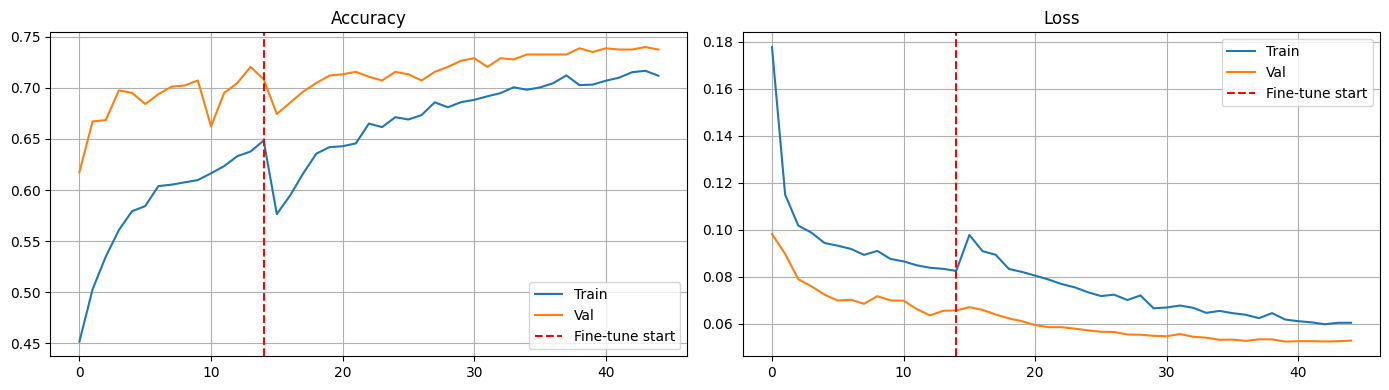

In [31]:
acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss = history1.history['loss'] + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(acc, label='Train'); axes[0].plot(val_acc, label='Val')
axes[0].axvline(x=len(history1.history['accuracy'])-1, color='r', linestyle='--', label='Fine-tune start')
axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(loss, label='Train'); axes[1].plot(val_loss, label='Val')
axes[1].axvline(x=len(history1.history['loss'])-1, color='r', linestyle='--', label='Fine-tune start')
axes[1].set_title('Loss'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.show()


## Evaluate on Test Set(2018)

52/52 ━━━━━━━━━━━━━━━━━━━━ 44s 838ms/step - accuracy: 0.7361 - loss: 0.0513
=== TEST SET RESULTS ===
Test Accuracy: 73.61%
Test Loss:     0.0513
52/52 ━━━━━━━━━━━━━━━━━━━━ 38s 683ms/step
--- Classification Report ---
              precision    recall  f1-score   support

     Healthy     0.7305    0.9594    0.8294       935
    Moderate     0.6290    0.2617    0.3697       447
      Severe     0.8471    0.7482    0.7946       274

    accuracy                         0.7361      1656
   macro avg     0.7355    0.6564    0.6645      1656
weighted avg     0.7224    0.7361    0.6995      1656



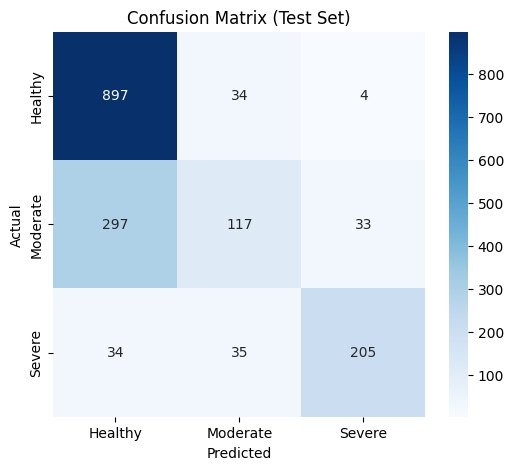

In [32]:
test_gen.reset()
loss, acc = model.evaluate(test_gen, verbose=1)
print(f"=== TEST SET RESULTS ===")
print(f"Test Accuracy: {acc*100:.2f}%")
print(f"Test Loss:     {loss:.4f}")

y_pred_probs = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

print("--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix (Test Set)')
plt.show()


In [33]:
# Evaluation on 2020 dataset
# The 2020 dataset uses folders like "0Normal", "1Doubtful" etc.
# We need to remap them into our ternary classes.

EXTRA_TERNARY_DIR = r"ternary_extra_test"

GRADE_MAP_2020 = {
    '0Normal':   'Healthy',
    '1Doubtful': 'Moderate',
    '2Mild':     'Moderate',
    '3Moderate': 'Severe',
    '4Severe':   'Severe',
}

if not os.path.exists(EXTRA_TERNARY_DIR):
    for src_folder, new_class in GRADE_MAP_2020.items():
        src_dir = os.path.join(EXTRA_TEST_DIR, src_folder)
        dst_dir = os.path.join(EXTRA_TERNARY_DIR, new_class)
        os.makedirs(dst_dir, exist_ok=True)
        for fname in os.listdir(src_dir):
            shutil.copy2(os.path.join(src_dir, fname),
                         os.path.join(dst_dir, fname))
    print("✓ Built extra test set")

extra_gen = eval_datagen.flow_from_directory(
    EXTRA_TERNARY_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
)

loss2, acc2 = model.evaluate(extra_gen, verbose=1)
print(f"2020 Dataset Accuracy: {acc2*100:.2f}%")

y_pred2 = np.argmax(model.predict(extra_gen, verbose=1), axis=1)
y_true2 = extra_gen.classes
print(classification_report(y_true2, y_pred2, target_names=CLASS_NAMES, digits=4))

✓ Built extra test set
Found 1650 images belonging to 3 classes.
52/52 ━━━━━━━━━━━━━━━━━━━━ 46s 885ms/step - accuracy: 0.4600 - loss: 0.1000
2020 Dataset Accuracy: 46.00%
52/52 ━━━━━━━━━━━━━━━━━━━━ 34s 643ms/step
              precision    recall  f1-score   support

     Healthy     0.7436    0.4514    0.5617       514
    Moderate     0.4531    0.1636    0.2404       709
      Severe     0.3799    0.9625    0.5447       427

    accuracy                         0.4600      1650
   macro avg     0.5255    0.5258    0.4490      1650
weighted avg     0.5246    0.4600    0.4193      1650



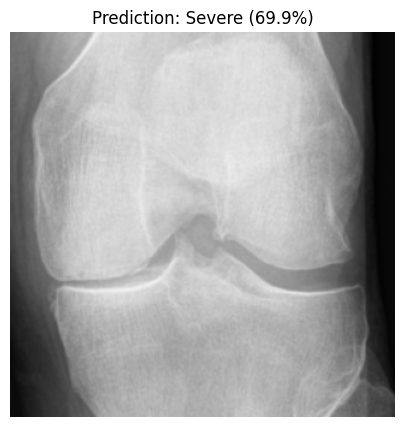

All class probabilities:
  Healthy   : 1.07%
  Moderate  : 29.05%
  Severe    : 69.88%


'Severe'

In [34]:
# Predict a single new x-ray image
def predict_xray(img_path, model, class_names):
    img = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    arr = np.expand_dims(np.array(img), axis=0).astype('float32')
    arr = preprocess_input(arr)
    probs = model.predict(arr, verbose=0)[0]
    pred_idx = int(np.argmax(probs))

    # Display
    plt.figure(figsize=(5, 5))
    plt.imshow(img); plt.axis('off')
    plt.title(f"Prediction: {class_names[pred_idx]} ({probs[pred_idx]*100:.1f}%)")
    plt.show()

    print("All class probabilities:")
    for cls, p in zip(class_names, probs):
        print(f"  {cls:10s}: {p*100:.2f}%")
    return class_names[pred_idx]

# Example usage — replace with any test image path
sample_img = os.path.join(TERNARY_DIR, 'test', 'Severe',os.listdir(os.path.join(TERNARY_DIR, 'test', 'Severe'))[0])
predict_xray(sample_img, model, CLASS_NAMES)

In [ ]:
## Save the Model
model.save('knee_oa_ternary_model.h5')
print("Model saved as 'knee_oa_ternary_model.h5'")

# To reload later:
# model = load_model('knee_oa_ternary_model.h5')
